In [1]:
import sys
from pathlib import Path

# Ensure project root is importable when notebook runs from notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: d:\Projet\scanned_images_classifier


# OCR Fine-tuning CPU (batch_1 -> batch_2)

Ce notebook entraine un modele OCR image->texte sur `batch_1` avec les annotations CSV (`batch1_1` + `batch1_3`) et evalue sur `batch1_2`, puis teste l'inference sur `batch_2`.


In [2]:
from pathlib import Path
import json

from src.ocr_image_text.config import TrainConfig, InferConfig
from src.ocr_image_text.data import resolve_default_data_root, load_default_train_eval
from src.ocr_image_text.train import run_training
from src.ocr_image_text.inference import load_predictor
from src.ocr_image_text.evaluation import evaluate_records

In [3]:
data_root = resolve_default_data_root()

# Force artifacts in notebooks/artifacts to avoid loading stale smoke models from ./artifacts
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
output_dir = (repo_root / "notebooks" / "artifacts" / "doc_understanding_ocr_cpu").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

legacy_output_dir = (repo_root / "artifacts" / "doc_understanding_ocr_cpu").resolve()
if legacy_output_dir.exists() and legacy_output_dir != output_dir:
    print(f"[info] Ignoring legacy artifacts at: {legacy_output_dir}")

print("data_root:", data_root)
print("output_dir (forced):", output_dir)


[info] Ignoring legacy artifacts at: D:\Projet\scanned_images_classifier\artifacts\doc_understanding_ocr_cpu
data_root: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3
output_dir (forced): D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu


In [4]:
train_csvs = (
    "batch_1/batch_1/batch1_1.csv",
    "batch_1/batch_1/batch1_3.csv",
)
train_image_subdirs = (
    "batch_1/batch_1/batch1_1",
    "batch_1/batch_1/batch1_3",
)

train_records, eval_records = load_default_train_eval(
    data_root=data_root,
    train_csvs=train_csvs,
    eval_csv="batch_1/batch_1/batch1_2.csv",
    image_subdirs_train=train_image_subdirs,
    image_subdir_eval="batch_1/batch_1/batch1_2",
)

print("num_train_records:", len(train_records))
print("num_eval_records:", len(eval_records))
print("sample_train_image:", train_records[0].image_path)
print("sample_train_text[:200]:", train_records[0].ocr_text[:200])


num_train_records: 988
num_eval_records: 426
sample_train_image: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3\batch_1\batch_1\batch1_1\batch1-0494.jpg
sample_train_text[:200]: Invoice no: 84652373 Date of issue: 02/23/2021 Seller: Client: Nguyen-Roach Clark-Foster 247 David Highway 77477 Cliff Apt. 853 Lake John, WV 84178 Washingtonbury, MS 78346 Tax Id: 991-72-5826 Tax Id:


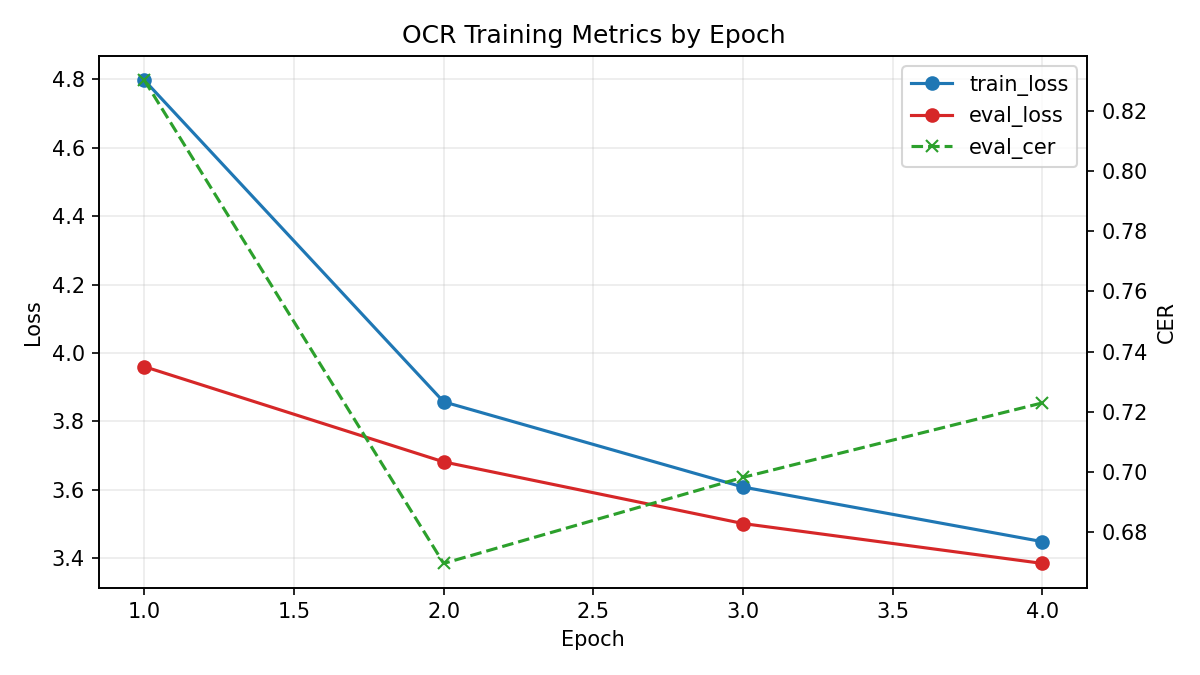

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'config': {'data_root': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub\\datasets\\osamahosamabdellatif\\high-quality-invoice-images-for-ocr\\versions\\3',
  'output_dir': 'D:\\Projet\\scanned_images_classifier\\notebooks\\artifacts\\doc_understanding_ocr_cpu',
  'model_name': 'microsoft/trocr-small-printed',
  'train_csvs': ('batch_1/batch_1/batch1_1.csv',
   'batch_1/batch_1/batch1_3.csv'),
  'eval_csv': 'batch_1/batch_1/batch1_2.csv',
  'image_subdirs_train': ('batch_1/batch_1/batch1_1',
   'batch_1/batch_1/batch1_3'),
  'image_subdir_eval': 'batch_1/batch_1/batch1_2',
  'max_train_samples': 0,
  'max_eval_samples': 0,
  'max_target_length': 256,
  'learning_rate': 3e-05,
  'train_epochs': 10,
  'per_device_train_batch_size': 2,
  'per_device_eval_batch_size': 2,
  'random_seed': 3407,
  'lr_scheduler_type': 'cosine',
  'early_stopping_patience': 2,
  'early_stopping_threshold': 0.0,
  'metric_for_best_model': 'eval_cer',
  'greater_is_better': False,
  'generation_num_beams': 4,


In [5]:
# Preset principal (8-12 epochs, early stopping actif)
MODEL_NAME = "microsoft/trocr-small-printed"
EPOCHS = 10
MAX_TRAIN_SAMPLES = 0  # <=0 => tout le train (batch1_1 + batch1_3)
MAX_EVAL_SAMPLES = 0   # <=0 => tout eval (batch1_2)
TRAIN_BATCH_SIZE = 2
EVAL_BATCH_SIZE = 2
LEARNING_RATE = 3e-5

cfg = TrainConfig(
    data_root=data_root,
    output_dir=output_dir,
    model_name=MODEL_NAME,
    train_csvs=train_csvs,
    eval_csv="batch_1/batch_1/batch1_2.csv",
    image_subdirs_train=train_image_subdirs,
    image_subdir_eval="batch_1/batch_1/batch1_2",
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_eval_samples=MAX_EVAL_SAMPLES,
    train_epochs=EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    generation_num_beams=4,
    generation_length_penalty=1.0,
    generation_no_repeat_ngram_size=3,
    generation_repetition_penalty=1.1,
)

summary = run_training(cfg)
summary


plot_path: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\training_metrics.png
history_path: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\metrics_history.json


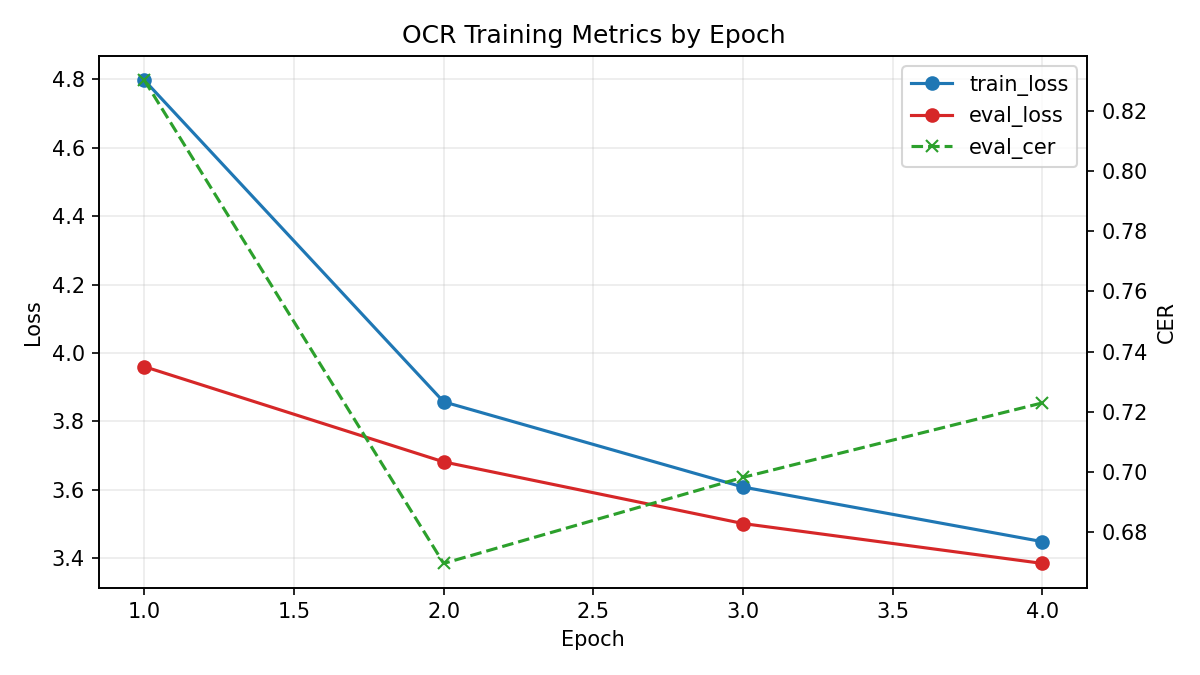

,epoch,loss
0,1.0,4.796910
1,2.0,3.857287
2,3.0,3.608376
3,4.0,3.448866


,epoch,loss,cer
0,1.0,3.960088,0.830272
1,2.0,3.681881,0.669542
2,3.0,3.501748,0.698171
3,4.0,3.385261,0.722934


C:\Users\Francis BACKELAND\AppData\Local\Temp\ipykernel_7612\543699508.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

plot_path = output_dir / "training_metrics.png"
history_path = output_dir / "metrics_history.json"

print("plot_path:", plot_path)
print("history_path:", history_path)
if plot_path.exists():
    display(Image(filename=str(plot_path)))
else:
    print("Plot not found yet.")

if history_path.exists():
    history = json.loads(history_path.read_text(encoding="utf-8"))
    train_df = pd.DataFrame(history.get("train", []))
    eval_df = pd.DataFrame(history.get("eval", []))
    display(train_df.tail())
    display(eval_df.tail())
    if eval_df.empty:
        print("Warning: no eval_loss logged yet. Check eval strategy / completed epoch.")

    plt.figure(figsize=(8,4))
    if not train_df.empty:
        plt.plot(train_df["epoch"], train_df["loss"], marker="o", label="train_loss")
    if not eval_df.empty:
        plt.plot(eval_df["epoch"], eval_df["loss"], marker="o", label="eval_loss")
    plt.title("Train vs Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()
else:
    print("metrics_history.json not found yet.")


In [7]:
# Cellule suivi tests + val loss
import subprocess, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

cmd = [
    sys.executable, "-m", "unittest", "discover",
    "-s", "tests/apps",
    "-p", "test_doc_understanding_cpu_gradio_smoke.py",
]
res = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PROJECT_ROOT))
print("--- unit tests stdout ---")
print(res.stdout)
print("--- unit tests stderr ---")
print(res.stderr)
print("returncode:", res.returncode)

if "metrics" in globals():
    print("current_val_metrics:", metrics)


--- unit tests stdout ---

--- unit tests stderr ---
..
----------------------------------------------------------------------
Ran 2 tests in 0.000s

OK

returncode: 0


In [8]:
eval_subset = eval_records[:100]
decode_grid = [
    {"num_beams": 4, "no_repeat_ngram_size": 3, "repetition_penalty": 1.10},
    {"num_beams": 6, "no_repeat_ngram_size": 4, "repetition_penalty": 1.10},
]

eval_runs = []
for grid in decode_grid:
    predictor_i = load_predictor(
        InferConfig(
            artifacts_dir=output_dir,
            max_new_tokens=256,
            num_beams=grid["num_beams"],
            length_penalty=1.0,
            no_repeat_ngram_size=grid["no_repeat_ngram_size"],
            repetition_penalty=grid["repetition_penalty"],
            temperature=0.0,
        )
    )
    preds = {}
    for rec in eval_subset:
        out = predictor_i.predict(rec.image_path)
        preds[rec.img_name] = out.get("prediction", "")
    m = evaluate_records(eval_subset, preds)
    eval_runs.append({"decode": grid, "metrics": m})

best_run = min(eval_runs, key=lambda x: x["metrics"].get("avg_cer", 1e9))
best_decode = best_run["decode"]
predictor = load_predictor(
    InferConfig(
        artifacts_dir=output_dir,
        max_new_tokens=256,
        num_beams=best_decode["num_beams"],
        length_penalty=1.0,
        no_repeat_ngram_size=best_decode["no_repeat_ngram_size"],
        repetition_penalty=best_decode["repetition_penalty"],
        temperature=0.0,
    )
)
best_run


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

{'decode': {'num_beams': 6,
  'no_repeat_ngram_size': 4,
  'repetition_penalty': 1.1},
 'metrics': {'num_samples': 100,
  'exact_match': 0.0,
  'avg_cer': 0.668902103243542,
  'avg_char_accuracy': 0.3310978967564581,
  'avg_word_accuracy': 0.270320172098333,
  'field_exact_match': {'invoice_no': 0.0,
   'date': 0.0,
   'total': 0.21,
   'vat': 0.05},
  'field_coverage': {'invoice_no': 100,
   'date': 100,
   'total': 100,
   'vat': 100}}}

In [9]:
metrics_payload = {
    "best_decode": best_decode,
    "best_metrics": best_run["metrics"],
    "all_decode_runs": eval_runs,
    "num_eval_samples": len(eval_subset),
}
metrics_path = output_dir / "eval_metrics.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2, ensure_ascii=False), encoding="utf-8")
print("saved:", metrics_path)
metrics_payload


saved: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\eval_metrics.json


{'best_decode': {'num_beams': 6,
  'no_repeat_ngram_size': 4,
  'repetition_penalty': 1.1},
 'best_metrics': {'num_samples': 100,
  'exact_match': 0.0,
  'avg_cer': 0.668902103243542,
  'avg_char_accuracy': 0.3310978967564581,
  'avg_word_accuracy': 0.270320172098333,
  'field_exact_match': {'invoice_no': 0.0,
   'date': 0.0,
   'total': 0.21,
   'vat': 0.05},
  'field_coverage': {'invoice_no': 100,
   'date': 100,
   'total': 100,
   'vat': 100}},
 'all_decode_runs': [{'decode': {'num_beams': 4,
    'no_repeat_ngram_size': 3,
    'repetition_penalty': 1.1},
   'metrics': {'num_samples': 100,
    'exact_match': 0.0,
    'avg_cer': 0.6703486870907667,
    'avg_char_accuracy': 0.32965131290923333,
    'avg_word_accuracy': 0.2580228269214444,
    'field_exact_match': {'invoice_no': 0.0,
     'date': 0.0,
     'total': 0.24,
     'vat': 0.14},
    'field_coverage': {'invoice_no': 100,
     'date': 100,
     'total': 100,
     'vat': 100}}},
  {'decode': {'num_beams': 6,
    'no_repeat_ngra

In [10]:
img_eval = data_root / "batch_1/batch_1/batch1_1/batch1-0001.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': 'Invoice no: 91889 Date of issue: 07/26/2016 Seller: Client: Johnson and Sons 838 South Apt: 934 West David, MN 574 Tax Id: 929-99-99-86 Tax Id : 949-86 IBAN: GB4SZJZHZIZHZKZZH3GB84064 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth 1. Nintendo 3,00 each 19,99 10% 19,99 10% 9,99 10% 4,00 each 5,00 10% 19,99 SUMMARY VAT Gross worth VAT Gross worth',
 'raw_output': 'Invoice no: 91889 Date of issue: 07/26/2016 Seller: Client: Johnson and Sons 838 South Apt: 934 West David, MN 574 Tax Id: 929-99-99-86 Tax Id : 949-86 IBAN: GB4SZJZHZIZHZKZZH3GB84064 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth 1. Nintendo 3,00 each 19,99 10% 19,99 10% 9,99 10% 4,00 each 5,00 10% 19,99 SUMMARY VAT Gross worth VAT Gross worth',
 'latency_ms': 30553.846}

In [11]:
# Test inference sur une image batch_2
batch2_image = data_root / "batch_2/batch_2/batch2_1/batch2-0001.jpg"
result_batch2 = predictor.predict(batch2_image)
result_batch2

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': 'Invoice no: 91889 Date of issue: 08/25/2016 Seller: Client: Johnson and Sons 564 South Apt: 924 North Garciamouth, UT 42974 Tax Id: 948-99-99-86 IBAN: GB4SZKJZZHZIZZZZZZKZZYZKY36884 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo SUMMARY VAT Gross worth VAT Gross worth 10% 66,00 Total $ 63,00 $ 394,99 $ 1 0,99 $ 1 87,95 $ 1 57,50 $ 1',
 'raw_output': 'Invoice no: 91889 Date of issue: 08/25/2016 Seller: Client: Johnson and Sons 564 South Apt: 924 North Garciamouth, UT 42974 Tax Id: 948-99-99-86 IBAN: GB4SZKJZZHZIZZZZZZKZZYZKY36884 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo SUMMARY VAT Gross worth VAT Gross worth 10% 66,00 Total $ 63,00 $ 394,99 $ 1 0,99 $ 1 87,95 $ 1 57,50 $ 1',
 'latency_ms': 28539.866}

## Test A/B

In [13]:
img_eval = data_root / "tests_AB/batch3-0501.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': 'Invoice no: 91889 Date of issue: 04/26/2016 Seller: Client: Johnson and Sons 574 South Apt: 934 West David, OH 478 Tax Id: 929-99-99-86 IBAN: GB4SZJZZHZIZZZZ6406864 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 3,00 each 4,00 10% 19,99 10% 19,99 SUMMARY VAT Gross worth VAT Gross worth',
 'raw_output': 'Invoice no: 91889 Date of issue: 04/26/2016 Seller: Client: Johnson and Sons 574 South Apt: 934 West David, OH 478 Tax Id: 929-99-99-86 IBAN: GB4SZJZZHZIZZZZ6406864 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 3,00 each 4,00 10% 19,99 10% 19,99 SUMMARY VAT Gross worth VAT Gross worth',
 'latency_ms': 17586.016}

In [14]:
img_eval = data_root / "tests_AB/facture_hors_corpus.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': 'Invoice no: 91889 Date of issue: 09/25/2016 Seller: Client: Johnson and Sons 838 South Apt: 924 North Garciamouth, OH 474 Tax Id: 929-98-99-86 IBAN: GB4SZIZJZZZHZZZKZYZZZIZX36864 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 3,00 each 4,00 each 19,99 10% 19,99 10% 11,99 10% 44,99 10% 65,99 10% 49,99 10% 45,00 each 5,00 10% 19,99 SUMMARY VAT Gross worth VAT Gross worth',
 'raw_output': 'Invoice no: 91889 Date of issue: 09/25/2016 Seller: Client: Johnson and Sons 838 South Apt: 924 North Garciamouth, OH 474 Tax Id: 929-98-99-86 IBAN: GB4SZIZJZZZHZZZKZYZZZIZX36864 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 3,00 each 4,00 each 19,99 10% 19,99 10% 11,99 10% 44,99 10% 65,99 10% 49,99 10% 45,00 each 5,00 10% 19,99 SUMMARY VAT Gross worth VAT Gross worth',
 'latency_ms': 24179.321}

In [15]:
img_eval = data_root / "tests_AB/avril2025auchan-local1704202519042029S0C0epagny-1.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': 'Invoice no: 91879 Date of issue: 11/27/2016 Seller: Client: Johnson and Sons Apt: 974 South Apt: 544 North Garciamouth, OH 478 Tax Id: 929-99-99-86 IBAN: GB4SZJZIZH4GB4896964 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 3,00 each 19,99 10% 19,99 10% 16,99 10% 4,00 each 5,99 10% 19,98',
 'raw_output': 'Invoice no: 91879 Date of issue: 11/27/2016 Seller: Client: Johnson and Sons Apt: 974 South Apt: 544 North Garciamouth, OH 478 Tax Id: 929-99-99-86 IBAN: GB4SZJZIZH4GB4896964 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 3,00 each 19,99 10% 19,99 10% 16,99 10% 4,00 each 5,99 10% 19,98',
 'latency_ms': 19032.146}

## Lancer Gradio avec ce modele

```bash
python src/apps/doc_understanding_cpu_gradio.py --model-dir notebooks/artifacts/doc_understanding_ocr_cpu/model --model-meta-path notebooks/artifacts/doc_understanding_ocr_cpu/model_meta.json --host 127.0.0.1 --port 7862
```

Conseil test decode: comparer `num_beams=4` et `num_beams=6`, puis `no_repeat_ngram_size=3/4` et `repetition_penalty=1.1`.
